# Build a simple workflow or graph using LangGraph

## State

In [1]:
from typing_extensions import TypedDict # TypedDict permet de définir un dictionnaire avec une structure typée.

class State(TypedDict):
    graph_info:str # clé obligatoire, info partagée entre nodes

Chaque node :

- reçoit un State
- le modifie
- renvoie un nouveau State

# Nodes

In [6]:
# 1er node
def start_play(state:State):
    print("Star_play mode has been called")
    return {"graph_info":state["graph_info"] + "I am planning to practice "} # Sous forme de dictionnaire car "TypeDict" qui est un dictionnaire

# 2e node
def climbing(state:State):
    print("My climbing node has been called ")
    return {"graph_info":state["graph_info"] + "Climbing"}

#3e node
def trail(state:State):
    print("My trail node has been called")
    return {"graph_info":state["graph_info"] + "Trail"}

## Conditional Edge

In [7]:
import random
from typing import Literal

# Fonction appelée avant les noeuds
def random_play(state:State)->Literal["climbing","trail"]:
    graph_info=state["graph_info"]

    if random.random()>0.5:
        return "climbing"
    else:
        return "trail"

# Graph construction

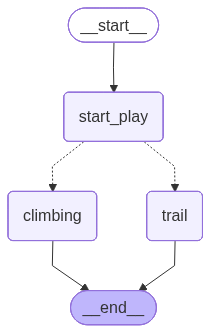

In [ ]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

# Build graph
graph=StateGraph(State)

# Adding the nodes
graph.add_node("start_play",start_play)
graph.add_node("climbing",climbing)
graph.add_node("trail",trail)

# Schedule the flow of the graph
graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("climbing",END)
graph.add_edge("trail",END)

# Compile the graph
graph_builder=graph.compile()

# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

# Graph invocation

In [9]:
graph_builder.invoke({"graph_info":"My name is Nicolas "})

Star_play mode has been called
My climbing node has been called 


{'graph_info': 'My name is Nicolas I am planning to practice Climbing'}